In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os, zipfile, urllib.request

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (SimpleRNN, LSTM, GRU, Dense, Dropout,
                                      Input, RepeatVector, TimeDistributed)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
               'SITTING', 'STANDING', 'LAYING']

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "UCI_HAR_Dataset.zip"
ROOT = "UCI HAR Dataset"

if not os.path.exists(ROOT):
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(".")
    print("Download and extraction complete.")
else:
    print("Dataset already present.")

SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z",
           "body_gyro_x", "body_gyro_y", "body_gyro_z",
           "total_acc_x", "total_acc_y", "total_acc_z"]

def load_signals(subset):
    data = []
    for sig in SIGNALS:
        path = f"{ROOT}/{subset}/Inertial Signals/{sig}_{subset}.txt"
        data.append(np.loadtxt(path))
    # stack -> (N, 128, 9)
    return np.stack(data, axis=-1)

def load_labels(subset):
    path = f"{ROOT}/{subset}/y_{subset}.txt"
    return np.loadtxt(path).astype(int) - 1  # zero-index

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full  = load_signals("test")
y_test_full  = load_labels("test")

X_all = np.concatenate([X_train_full, X_test_full], axis=0)
y_all = np.concatenate([y_train_full, y_test_full], axis=0)

print("Full pooled signal tensor shape:", X_all.shape)
print("Full pooled label vector shape :", y_all.shape)

Download and extraction complete.
Full pooled signal tensor shape: (10299, 128, 9)
Full pooled label vector shape : (10299,)


In [3]:
N_SUBSET = 3000

X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all, train_size=N_SUBSET, stratify=y_all, random_state=SEED
)

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# Normalize using TRAIN statistics only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_val_n   = (X_val - mean) / std
X_test_n  = (X_test - mean) / std

print("Input tensor shape:")
print(f"Training   : {X_train_n.shape}")
print(f"Validation : {X_val_n.shape}")
print(f"Testing    : {X_test_n.shape}")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")

print("\nClass distribution (train):")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution (val):")
print(pd.Series(y_val).value_counts().sort_index())
print("\nClass distribution (test):")
print(pd.Series(y_test).value_counts().sort_index())

Input tensor shape:
Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train):
0    351
1    315
2    286
3    363
4    389
5    396
Name: count, dtype: int64

Class distribution (val):
0    76
1    68
2    61
3    77
4    83
5    85
Name: count, dtype: int64

Class distribution (test):
0    75
1    67
2    62
3    78
4    83
5    85
Name: count, dtype: int64


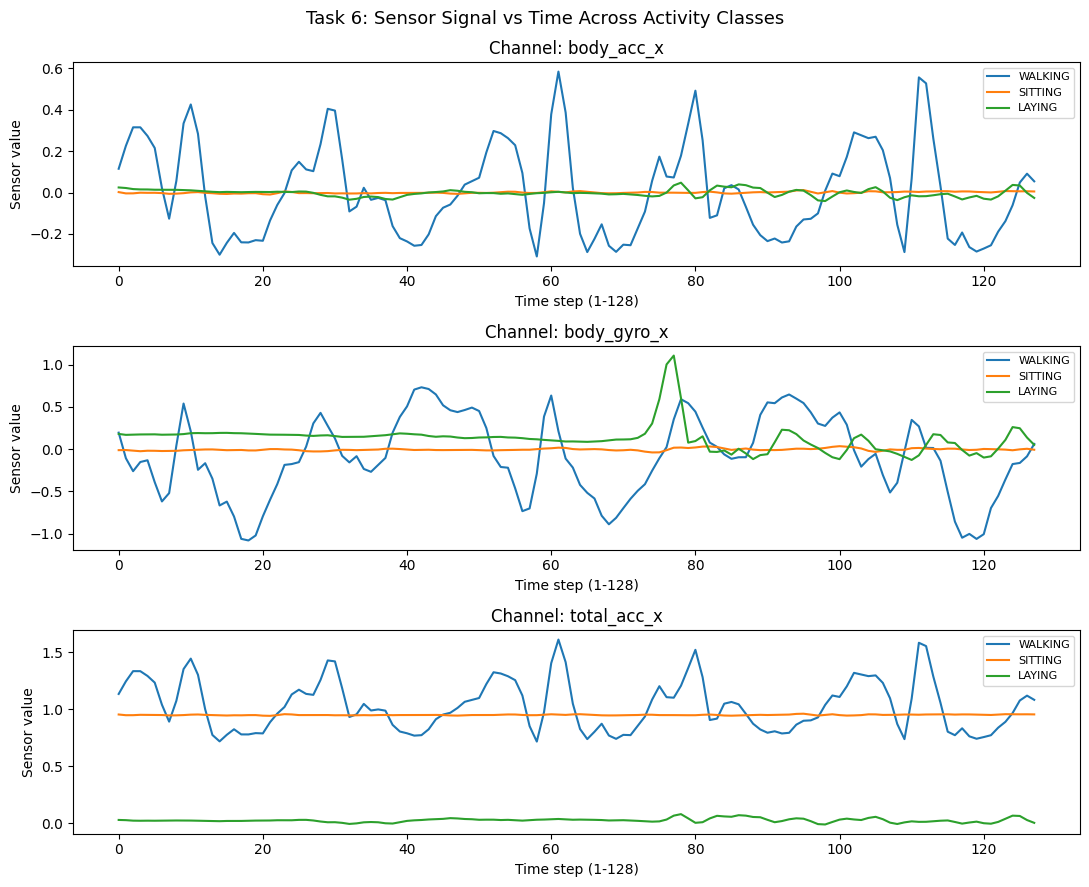

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
channel_idx = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x
channel_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
picked_classes = [0, 3, 5]  # WALKING, SITTING, LAYING

for ax, ch, chname in zip(axes, channel_idx, channel_names):
    for cls in picked_classes:
        idx = np.where(y_train == cls)[0][0]
        ax.plot(X_train[idx, :, ch], label=CLASS_NAMES[cls])
    ax.set_title(f"Channel: {chname}")
    ax.set_xlabel("Time step (1-128)")
    ax.set_ylabel("Sensor value")
    ax.legend(fontsize=8)

plt.suptitle("Task 6: Sensor Signal vs Time Across Activity Classes", fontsize=13)
plt.tight_layout()
plt.savefig("plot1_temporal_signals.png", dpi=130, bbox_inches="tight")
plt.show()

In [5]:
x = [0.5, 0.7, 0.2]
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

h_prev = h0
h_values = []
for t, xt in enumerate(x, start=1):
    h_t = np.tanh(Wx * xt + Wh * h_prev + b)
    h_values.append(h_t)
    print(f"h{t} = tanh({Wx}*{xt} + {Wh}*{h_prev:.6f} + {b}) = {h_t:.6f}")
    h_prev = h_t

print("\nManual h1, h2, h3:", [round(v, 6) for v in h_values])

h1 = tanh(0.5*0.5 + 0.8*0.000000 + 0.1) = 0.336376
h2 = tanh(0.5*0.7 + 0.8*0.336376 + 0.1) = 0.616352
h3 = tanh(0.5*0.2 + 0.8*0.616352 + 0.1) = 0.599958

Manual h1, h2, h3: [np.float64(0.336376), np.float64(0.616352), np.float64(0.599958)]


In [6]:
def build_model(recurrent_layer, units=32, T=128, F=9, num_classes=6):
    model = Sequential([
        Input(shape=(T, F)),
        recurrent_layer(units, dropout=0.0, recurrent_dropout=0.0),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def train_and_evaluate(layer_class, name, X_tr, y_tr, X_v, y_v, X_te, y_te,
                        units=32, epochs=30, batch_size=32):
    tf.random.set_seed(SEED)
    model = build_model(layer_class, units=units, T=X_tr.shape[1], F=X_tr.shape[2])
    n_params = model.count_params()

    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=batch_size, verbose=2)
    train_time = time.time() - t0

    y_pred_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_te, y_pred)

    print(f"\n=== {name} ===")
    print(f"Params: {n_params} | Train time: {train_time:.2f}s")
    print(f"Test Accuracy: {acc:.4f} | Macro P: {prec:.4f} | Macro R: {rec:.4f} | Macro F1: {f1:.4f}")

    return {
        "name": name, "model": model, "history": history,
        "params": n_params, "time": train_time,
        "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "cm": cm, "y_pred": y_pred
    }

In [7]:
results = {}
results["RNN"]  = train_and_evaluate(SimpleRNN, "RNN",  X_train_n, y_train, X_val_n, y_val, X_test_n, y_test)
results["LSTM"] = train_and_evaluate(LSTM,      "LSTM", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test)
results["GRU"]  = train_and_evaluate(GRU,       "GRU",  X_train_n, y_train, X_val_n, y_val, X_test_n, y_test)

Epoch 1/30
66/66 - 7s - 109ms/step - accuracy: 0.4619 - loss: 1.4072 - val_accuracy: 0.5289 - val_loss: 1.1976
Epoch 2/30
66/66 - 2s - 36ms/step - accuracy: 0.5595 - loss: 1.1303 - val_accuracy: 0.5489 - val_loss: 1.0248
Epoch 3/30
66/66 - 2s - 35ms/step - accuracy: 0.5876 - loss: 1.0131 - val_accuracy: 0.6044 - val_loss: 0.9226
Epoch 4/30
66/66 - 1s - 16ms/step - accuracy: 0.6381 - loss: 0.8772 - val_accuracy: 0.6578 - val_loss: 0.7637
Epoch 5/30
66/66 - 1s - 22ms/step - accuracy: 0.6829 - loss: 0.7518 - val_accuracy: 0.6756 - val_loss: 0.6855
Epoch 6/30
66/66 - 4s - 63ms/step - accuracy: 0.6781 - loss: 0.7358 - val_accuracy: 0.7067 - val_loss: 0.6782
Epoch 7/30
66/66 - 3s - 48ms/step - accuracy: 0.7014 - loss: 0.6750 - val_accuracy: 0.7222 - val_loss: 0.6164
Epoch 8/30
66/66 - 1s - 17ms/step - accuracy: 0.7190 - loss: 0.6357 - val_accuracy: 0.7222 - val_loss: 0.5997
Epoch 9/30
66/66 - 1s - 17ms/step - accuracy: 0.7271 - loss: 0.6108 - val_accuracy: 0.7467 - val_loss: 0.5863
Epoch 10/

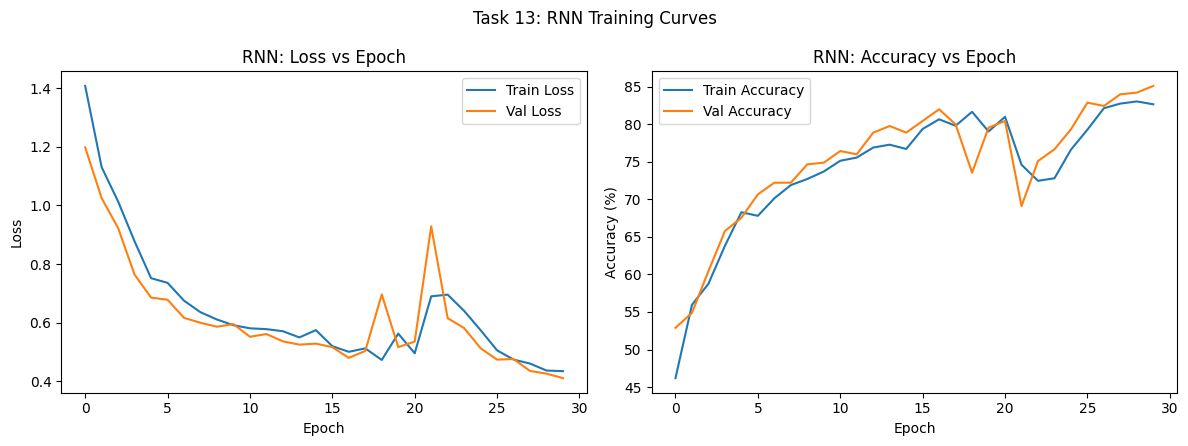

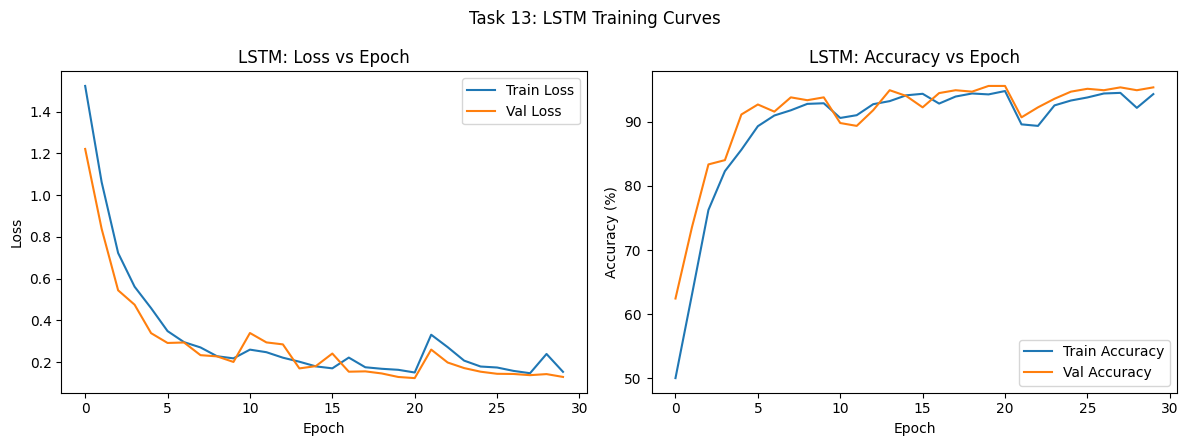

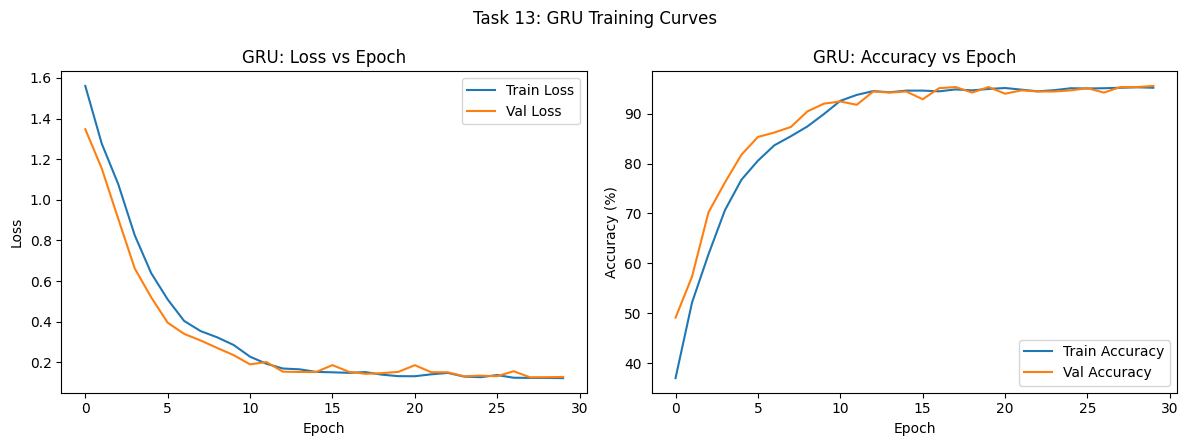

In [8]:
for name, res in results.items():
    h = res["history"].history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(h['loss'], label='Train Loss')
    axes[0].plot(h['val_loss'], label='Val Loss')
    axes[0].set_title(f"{name}: Loss vs Epoch")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(np.array(h['accuracy'])*100, label='Train Accuracy')
    axes[1].plot(np.array(h['val_accuracy'])*100, label='Val Accuracy')
    axes[1].set_title(f"{name}: Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.suptitle(f"Task 13: {name} Training Curves")
    plt.tight_layout()
    plt.savefig(f"plot23_{name}_curves.png", dpi=130, bbox_inches="tight")
    plt.show()

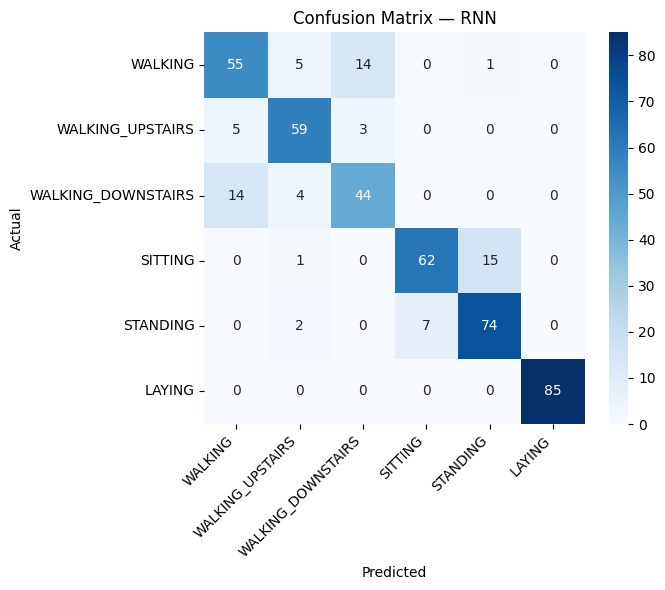


RNN Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.74      0.73      0.74        75
  WALKING_UPSTAIRS       0.83      0.88      0.86        67
WALKING_DOWNSTAIRS       0.72      0.71      0.72        62
           SITTING       0.90      0.79      0.84        78
          STANDING       0.82      0.89      0.86        83
            LAYING       1.00      1.00      1.00        85

          accuracy                           0.84       450
         macro avg       0.84      0.84      0.83       450
      weighted avg       0.84      0.84      0.84       450



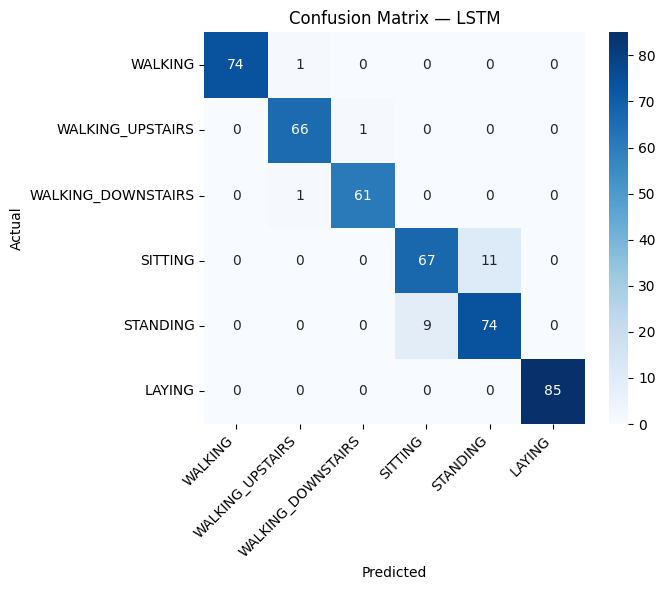


LSTM Classification Report:
                    precision    recall  f1-score   support

           WALKING       1.00      0.99      0.99        75
  WALKING_UPSTAIRS       0.97      0.99      0.98        67
WALKING_DOWNSTAIRS       0.98      0.98      0.98        62
           SITTING       0.88      0.86      0.87        78
          STANDING       0.87      0.89      0.88        83
            LAYING       1.00      1.00      1.00        85

          accuracy                           0.95       450
         macro avg       0.95      0.95      0.95       450
      weighted avg       0.95      0.95      0.95       450



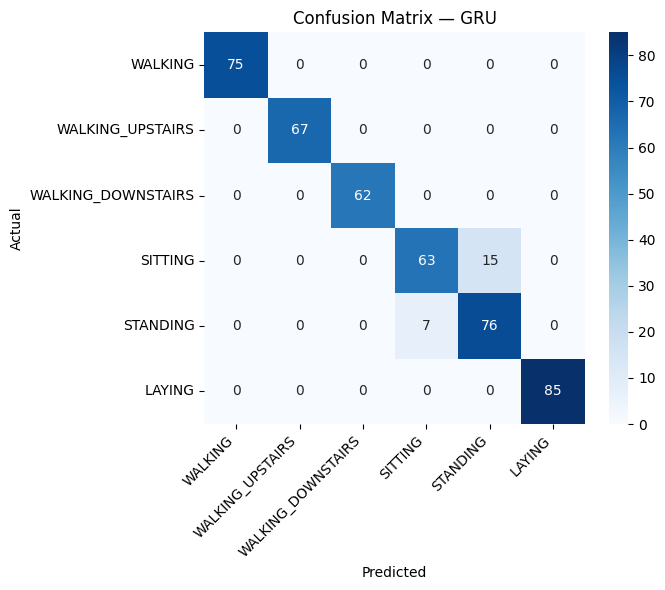


GRU Classification Report:
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00        75
  WALKING_UPSTAIRS       1.00      1.00      1.00        67
WALKING_DOWNSTAIRS       1.00      1.00      1.00        62
           SITTING       0.90      0.81      0.85        78
          STANDING       0.84      0.92      0.87        83
            LAYING       1.00      1.00      1.00        85

          accuracy                           0.95       450
         macro avg       0.96      0.95      0.95       450
      weighted avg       0.95      0.95      0.95       450



In [9]:
for name, res in results.items():
    plt.figure(figsize=(7, 6))
    sns.heatmap(res["cm"], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"plot4_{name}_confusion.png", dpi=130, bbox_inches="tight")
    plt.show()

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, res["y_pred"], target_names=CLASS_NAMES, zero_division=0))

  Model  Accuracy(%)  Macro Precision(%)  Macro Recall(%)  Macro F1(%)  \
0   RNN    84.222222           83.605226        83.500764    83.463390   
1  LSTM    94.888889           95.110440        95.102548    95.100326   
2   GRU    95.111111           95.586081        95.389249    95.415243   

   Parameters  Training Time(s)  
0        1974         64.187945  
1        6006         89.588699  
2        4758        128.979355  


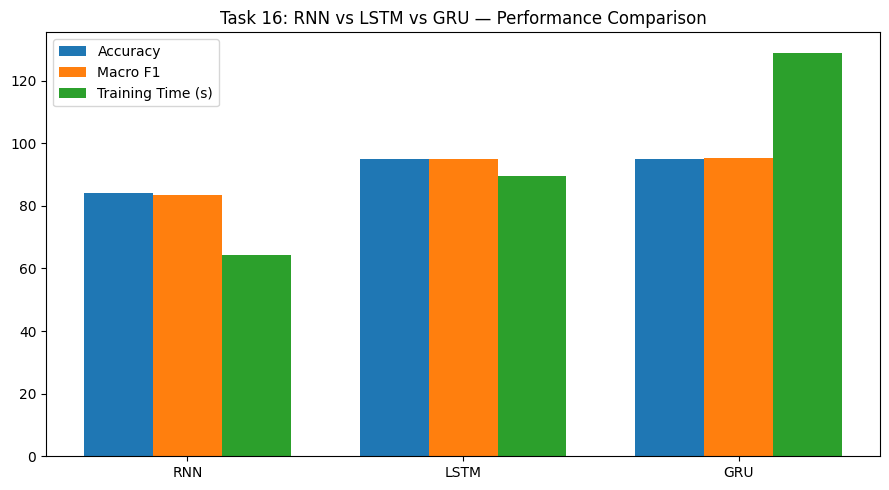

In [10]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy(%)": [results[m]["acc"]*100 for m in results],
    "Macro Precision(%)": [results[m]["prec"]*100 for m in results],
    "Macro Recall(%)": [results[m]["rec"]*100 for m in results],
    "Macro F1(%)": [results[m]["f1"]*100 for m in results],
    "Parameters": [results[m]["params"] for m in results],
    "Training Time(s)": [results[m]["time"] for m in results],
})
comparison.to_csv("comparison_rnn_lstm_gru.csv", index=False)
print(comparison)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
width = 0.25
ax.bar(x - width, comparison["Accuracy(%)"], width, label="Accuracy")
ax.bar(x, comparison["Macro F1(%)"], width, label="Macro F1")
ax.bar(x + width, comparison["Training Time(s)"], width, label="Training Time (s)")
ax.set_xticks(x); ax.set_xticklabels(comparison["Model"])
ax.set_title("Task 16: RNN vs LSTM vs GRU — Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot5_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

Epoch 1/20
66/66 - 3s - 41ms/step - accuracy: 0.3790 - loss: 1.5658 - val_accuracy: 0.5289 - val_loss: 1.3029
Epoch 2/20
66/66 - 0s - 7ms/step - accuracy: 0.5495 - loss: 1.2153 - val_accuracy: 0.5756 - val_loss: 1.0748
Epoch 3/20
66/66 - 0s - 7ms/step - accuracy: 0.5862 - loss: 1.0733 - val_accuracy: 0.6289 - val_loss: 0.9915
Epoch 4/20
66/66 - 1s - 10ms/step - accuracy: 0.6262 - loss: 0.9632 - val_accuracy: 0.6689 - val_loss: 0.8561
Epoch 5/20
66/66 - 0s - 7ms/step - accuracy: 0.6505 - loss: 0.8754 - val_accuracy: 0.6778 - val_loss: 0.7758
Epoch 6/20
66/66 - 0s - 8ms/step - accuracy: 0.6781 - loss: 0.7947 - val_accuracy: 0.6844 - val_loss: 0.7389
Epoch 7/20
66/66 - 0s - 7ms/step - accuracy: 0.6790 - loss: 0.7491 - val_accuracy: 0.6800 - val_loss: 0.6825
Epoch 8/20
66/66 - 0s - 8ms/step - accuracy: 0.7000 - loss: 0.6991 - val_accuracy: 0.7022 - val_loss: 0.6509
Epoch 9/20
66/66 - 0s - 7ms/step - accuracy: 0.7029 - loss: 0.6738 - val_accuracy: 0.6978 - val_loss: 0.6385
Epoch 10/20
66/66

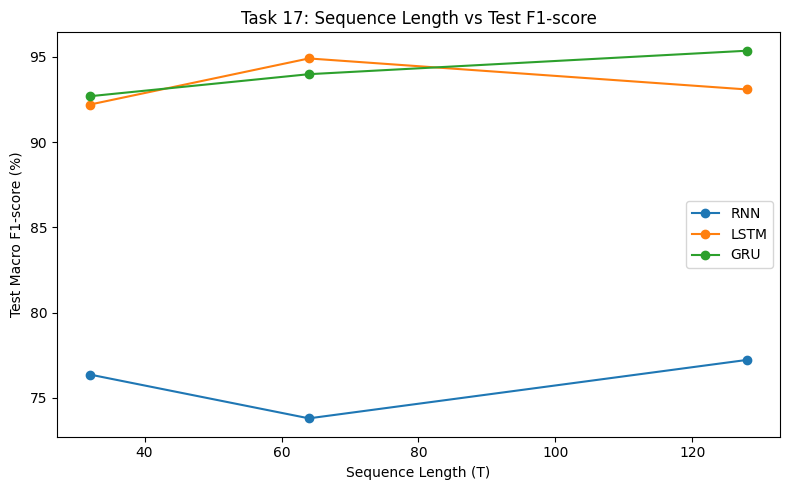

In [11]:
def truncate_sequences(X, T):
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_results = {m: [] for m in ["RNN", "LSTM", "GRU"]}

for T in seq_lengths:
    Xtr_T = truncate_sequences(X_train_n, T)
    Xv_T  = truncate_sequences(X_val_n, T)
    Xte_T = truncate_sequences(X_test_n, T)

    for layer_class, name in [(SimpleRNN, "RNN"), (LSTM, "LSTM"), (GRU, "GRU")]:
        res = train_and_evaluate(layer_class, f"{name}_T{T}",
                                  Xtr_T, y_train, Xv_T, y_val, Xte_T, y_test,
                                  epochs=20)
        seqlen_results[name].append(res["f1"])

seqlen_df = pd.DataFrame(seqlen_results, index=seq_lengths)
seqlen_df.index.name = "Sequence Length"
seqlen_df.to_csv("seqlen_f1_comparison.csv")
print(seqlen_df)

plt.figure(figsize=(8, 5))
for name in ["RNN", "LSTM", "GRU"]:
    plt.plot(seq_lengths, np.array(seqlen_results[name])*100, marker='o', label=name)
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Task 17: Sequence Length vs Test F1-score")
plt.legend()
plt.tight_layout()
plt.savefig("plot6_seqlen_vs_f1.png", dpi=130, bbox_inches="tight")
plt.show()

In [12]:
VOCAB_MIN, VOCAB_MAX = 1, 9
SEQ_LEN = 4
N_SAMPLES = 5000

def make_reversal_dataset(n, seq_len):
    X, Y = [], []
    for _ in range(n):
        seq = np.random.randint(VOCAB_MIN, VOCAB_MAX + 1, size=seq_len)
        X.append(seq)
        Y.append(seq[::-1])
    return np.array(X), np.array(Y)

X_seq, Y_seq = make_reversal_dataset(N_SAMPLES, SEQ_LEN)

# one-hot encode (vocab includes 0 as padding/start if needed; here just digits 1-9 -> 10 classes incl 0)
NUM_TOKENS = VOCAB_MAX + 1  # 0..9

X_seq_oh = to_categorical(X_seq, num_classes=NUM_TOKENS)
Y_seq_oh = to_categorical(Y_seq, num_classes=NUM_TOKENS)

Xs_train, Xs_test, Ys_train, Ys_test = train_test_split(
    X_seq_oh, Y_seq_oh, test_size=0.2, random_state=SEED
)
Xs_train, Xs_val, Ys_train, Ys_val = train_test_split(
    Xs_train, Ys_train, test_size=0.15, random_state=SEED
)

print("Seq2Seq input shape :", Xs_train.shape)
print("Seq2Seq output shape:", Ys_train.shape)

Seq2Seq input shape : (3400, 4, 10)
Seq2Seq output shape: (3400, 4, 10)


In [13]:
latent_dim = 64

enc_inputs = Input(shape=(SEQ_LEN, NUM_TOKENS))
encoder = LSTM(latent_dim)(enc_inputs)
repeat = RepeatVector(SEQ_LEN)(encoder)
decoder = LSTM(latent_dim, return_sequences=True)(repeat)
outputs = TimeDistributed(Dense(NUM_TOKENS, activation='softmax'))(decoder)

seq2seq_model = Model(enc_inputs, outputs)
seq2seq_model.compile(optimizer='adam', loss='categorical_crossentropy',
                       metrics=['accuracy'])
seq2seq_model.summary()

t0 = time.time()
seq2seq_history = seq2seq_model.fit(
    Xs_train, Ys_train, validation_data=(Xs_val, Ys_val),
    epochs=40, batch_size=64, verbose=2
)
seq2seq_time = time.time() - t0
print(f"\nSeq2Seq training time: {seq2seq_time:.2f}s")

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 4, 10)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 4, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 4, 10)          │           650 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,874 (206.54 KB)

 Trainable params: 52,874 (206.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
54/54 - 5s - 95ms/step - accuracy: 0.3032 - loss: 2.1615 - val_accuracy: 0.3629 - val_loss: 1.8027
Epoch 2/40
54/54 - 0s - 9ms/step - accuracy: 0.3822 - loss: 1.5575 - val_accuracy: 0.3892 - val_loss: 1.4229
Epoch 3/40
54/54 - 0s - 9ms/step - accuracy: 0.3878 - loss: 1.3797 - val_accuracy: 0.3854 - val_loss: 1.3415
Epoch 4/40
54/54 - 1s - 12ms/step - accuracy: 0.3908 - loss: 1.3102 - val_accuracy: 0.3971 - val_loss: 1.2841
Epoch 5/40
54/54 - 0s - 9ms/step - accuracy: 0.4049 - loss: 1.2459 - val_accuracy: 0.4121 - val_loss: 1.2231
Epoch 6/40
54/54 - 1s - 12ms/step - accuracy: 0.4399 - loss: 1.1719 - val_accuracy: 0.4621 - val_loss: 1.1451
Epoch 7/40
54/54 - 1s - 11ms/step - accuracy: 0.5124 - loss: 1.0648 - val_accuracy: 0.5342 - val_loss: 1.0256
Epoch 8/40
54/54 - 1s - 12ms/step - accuracy: 0.5892 - loss: 0.9305 - val_accuracy: 0.6092 - val_loss: 0.8975
Epoch 9/40
54/54 - 1s - 9ms/step - accuracy: 0.6613 - loss: 0.8058 - val_accuracy: 0.6687 - val_loss: 0.7816
Epoch 10/40
54

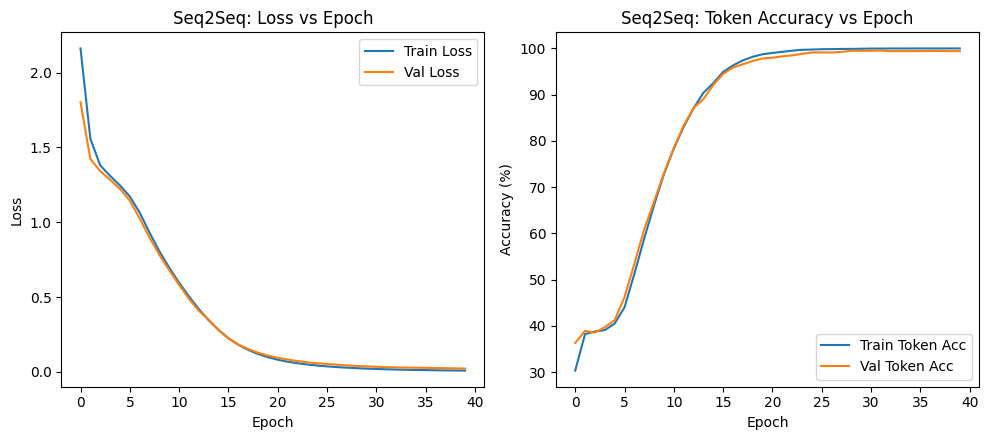

Token Accuracy   : 0.9962
Sequence Accuracy: 0.9860

Sample predictions:
Input: [8, 7, 7, 6]  ->  Predicted: [6, 7, 7, 8]  |  True: [6, 7, 7, 8]
Input: [3, 8, 8, 6]  ->  Predicted: [6, 8, 8, 3]  |  True: [6, 8, 8, 3]
Input: [8, 9, 3, 6]  ->  Predicted: [6, 3, 9, 8]  |  True: [6, 3, 9, 8]
Input: [1, 8, 8, 2]  ->  Predicted: [2, 8, 8, 1]  |  True: [2, 8, 8, 1]
Input: [4, 6, 3, 5]  ->  Predicted: [5, 3, 6, 4]  |  True: [5, 3, 6, 4]


In [14]:
h = seq2seq_history.history
plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
plt.plot(h['loss'], label='Train Loss')
plt.plot(h['val_loss'], label='Val Loss')
plt.title("Seq2Seq: Loss vs Epoch"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.array(h['accuracy'])*100, label='Train Token Acc')
plt.plot(np.array(h['val_accuracy'])*100, label='Val Token Acc')
plt.title("Seq2Seq: Token Accuracy vs Epoch"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend()

plt.tight_layout()
plt.savefig("plot7_seq2seq_curves.png", dpi=130, bbox_inches="tight")
plt.show()

# Evaluation on test set
pred_probs = seq2seq_model.predict(Xs_test, verbose=0)
pred_tokens = np.argmax(pred_probs, axis=-1)
true_tokens = np.argmax(Ys_test, axis=-1)

token_acc = (pred_tokens == true_tokens).mean()
seq_acc = np.all(pred_tokens == true_tokens, axis=1).mean()

print(f"Token Accuracy   : {token_acc:.4f}")
print(f"Sequence Accuracy: {seq_acc:.4f}")

input_tokens = np.argmax(Xs_test, axis=-1)
print("\nSample predictions:")
for i in range(5):
    print(f"Input: {input_tokens[i].tolist()}  ->  Predicted: {pred_tokens[i].tolist()}  |  True: {true_tokens[i].tolist()}")